# Leaky Integrate-and-Fire (LIF) neuron theory

A simple spiking neuron can be modeled with a membrane voltage $v(t)$ that changes over time according to:

$$
\tau_m \frac{dv}{dt} = -(v - V_{rest}) + I(t)
$$

where:
- $\tau_m$ is the membrane time constant
- $V_{rest}$ is the resting potential
- $I(t)$ is the input current

This equation says that the neuron integrates input current while it leaks back toward its resting value. When the voltage reaches a threshold $V_{th}$, the neuron emits a spike and then resets to $V_{reset}$ for a short refractory period $T_{ref}$.

In practice, the discrete-time update is:

$$
v[k] = v[k-1] + \frac{DT}{\tau_m}\left(-(v[k-1] - V_{rest}) + I[k-1]\right)
$$

with the rule:
- if $v[k] \ge V_{th}$: spike occurs, then set $v[k] = V_{reset}$
- during the refractory period, the neuron cannot spike again immediately

This is the core idea behind the simulations below: the neuron charges up with input, leaks back toward rest, spikes when threshold is crossed, and enters a brief reset period.

The code that follows explores:
1. charging without spiking
2. single-neuron spike generation under constant input
3. frequency-current relationship comparing simulation to theory
4. Poisson input driving firing rate output

In [2]:
import numpy as np
import matplotlib.pyplot as plt

In [4]:
V_REST, V_TH, V_RESET = -52.0, -45.0, -52.0  #mV
TAU_M, T_REF, DT = 20.0, 2.2, 0.1

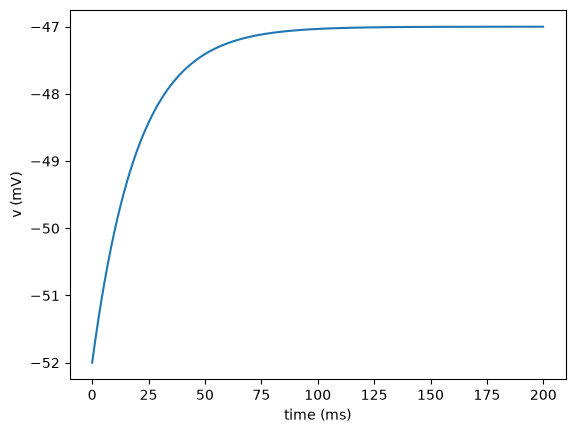

In [5]:
def charge_only(I_mv, T_ms=200.0):
    n = int(T_ms / DT)
    v = np.full(n, V_REST)
    for k in range(1, n):
        v[k] = v[k-1] + DT / TAU_M * (-(v[k-1] - V_REST) + I_mv)
    return np.arange(n) * DT, v

t, v = charge_only(5.0)
plt.plot(t, v); plt.xlabel("time (ms)"); plt.ylabel("v (mV)"); plt.show()

12 spikes


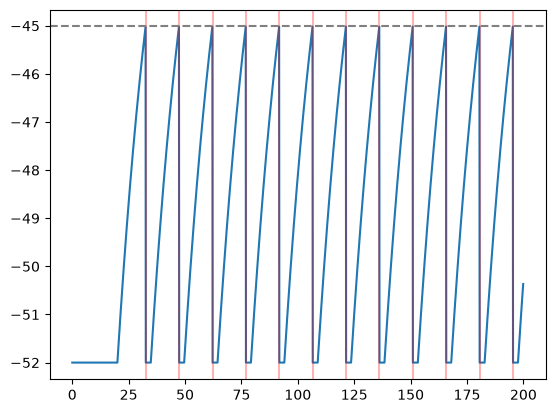

In [6]:
def simulate_lif(I, T_ms=200.0):
    """I: array of input (mV), one value per time step."""
    n = int(T_ms / DT)
    t = np.arange(n) * DT
    v = np.full(n, V_REST)
    spikes, refr = [], 0
    for k in range(1, n):
        if refr > 0:                       # dead time after a spike
            v[k] = V_RESET; refr -= 1
            continue
        v[k] = v[k-1] + DT / TAU_M * (-(v[k-1] - V_REST) + I[k-1])
        if v[k] >= V_TH:                   # comparator trips
            spikes.append(t[k])
            v[k] = V_RESET
            refr = int(round(T_REF / DT))
    return t, v, np.array(spikes)

n = 2000
I = np.zeros(n); I[200:] = 15.0            # input switches on at 20 ms
t, v, s = simulate_lif(I)
print(f"{len(s)} spikes")
plt.plot(t, v)
for x in s: plt.axvline(x, color="red", alpha=0.3)
plt.axhline(V_TH, ls="--", color="gray"); plt.show()

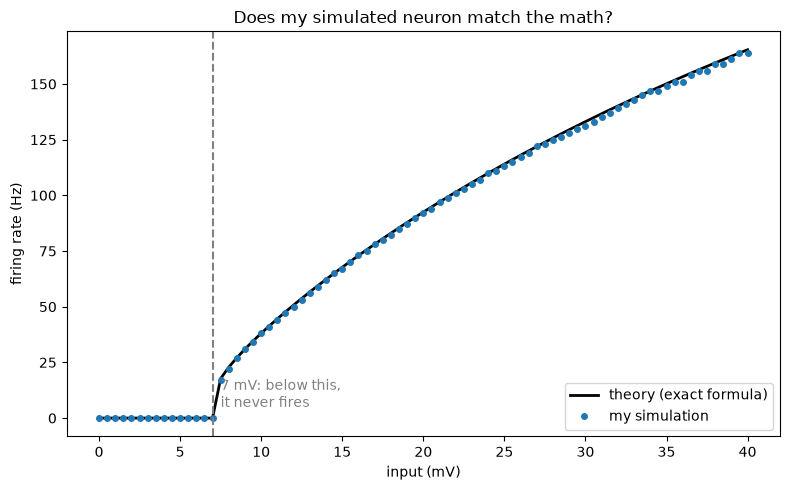

8 mV: simulation 22 Hz, theory 22.8 Hz
15 mV: simulation 67 Hz, theory 67.7 Hz
30 mV: simulation 131 Hz, theory 133.1 Hz


In [9]:
THETA = V_TH - V_REST            # 7 mV: how far threshold is above rest

def theory_rate(I):
    """Exact LIF firing rate (Hz) for constant input I (mV)."""
    if I <= THETA:
        return 0.0
    return 1000 / (T_REF + TAU_M * np.log(I / (I - THETA)))

inputs = np.arange(0, 40.5, 0.5)
sim_rates = []
for I in inputs:
    _, _, spikes = simulate_lif(np.full(10000, I), T_ms=1000)   # 1 second
    sim_rates.append(len(spikes))                                # spikes in 1 s = Hz
theory_rates = [theory_rate(I) for I in inputs]

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(inputs, theory_rates, color="black", lw=2, label="theory (exact formula)")
ax.plot(inputs, sim_rates, "o", ms=4, color="tab:blue", label="my simulation")
ax.axvline(THETA, ls="--", color="gray")
ax.text(THETA + 0.5, 5, "7 mV: below this,\nit never fires", color="gray")
ax.set_xlabel("input (mV)"); ax.set_ylabel("firing rate (Hz)")
ax.set_title("Does my simulated neuron match the math?")
ax.legend(); plt.tight_layout()
plt.savefig("fi_curve.png", dpi=200)
plt.show()

for I in [8, 15, 30]:
    i = int(I / 0.5)
    print(f"{I} mV: simulation {sim_rates[i]} Hz, theory {theory_rates[i]:.1f} Hz")

In [11]:
for dt in [0.2, 0.1, 0.05, 0.01]:
    DT = dt
    n = int(1000 / DT)
    _, _, s = simulate_lif(np.full(n, 15.0), T_ms=1000)
    print(f"dt = {dt} ms -> {len(s)} Hz   (theory {theory_rate(15):.1f} Hz)")
DT = 0.1 

dt = 0.2 ms -> 67 Hz   (theory 67.7 Hz)
dt = 0.1 ms -> 67 Hz   (theory 67.7 Hz)
dt = 0.05 ms -> 67 Hz   (theory 67.7 Hz)
dt = 0.01 ms -> 67 Hz   (theory 67.7 Hz)


In [12]:
def simulate_poisson(rate_hz, kick_mv=2.0, T_ms=1000, seed=0):
    rng = np.random.default_rng(seed)
    n = int(T_ms / DT)
    arrivals = rng.random(n) < rate_hz * DT / 1000
    v, count, refr = V_REST, 0, 0
    for k in range(n):
        if refr > 0:
            refr -= 1; continue
        v += -(v - V_REST) / TAU_M * DT
        if arrivals[k]:
            v += kick_mv
        if v >= V_TH:
            count += 1; v = V_RESET; refr = int(round(T_REF / DT))
    return count

for seed in range(5):
    print(f"seed {seed}: 150 Hz in -> {simulate_poisson(150, seed=seed)} Hz out")

seed 0: 150 Hz in -> 17 Hz out
seed 1: 150 Hz in -> 16 Hz out
seed 2: 150 Hz in -> 23 Hz out
seed 3: 150 Hz in -> 25 Hz out
seed 4: 150 Hz in -> 26 Hz out
